In [7]:
!pip install "numpy<2.4"



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import bst
import pandas as pd
import shap
from PIL.ImageOps import scale
from plotly.graph_objs.indicator.gauge import threshold
from sklearn import pipeline
from xgboost.interpret import shap_values

url = 'https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv'

df = pd.read_csv(url)
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
#Problema de classificação desbalanceada

df['Class'].value_counts(normalize=True)


Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

In [10]:
#Feature Engineering

import numpy as np
df['Amount_log'] = np.log1p(df['Amount'])

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Amount_log'] = scaler.fit_transform(df[['Amount']])


In [12]:
from sklearn.model_selection import train_test_split

x = df.drop('Class', axis=1)
y = df['Class']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, stratify= y, test_size= 0.3, random_state= 42
)

In [6]:
#Logistic Regression

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter= 1000)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

C:\Users\Meirielly\PycharmProjects\Estudos_Python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.87      0.66      0.75       148

    accuracy                           1.00     85443
   macro avg       0.93      0.83      0.88     85443
weighted avg       1.00      1.00      1.00     85443



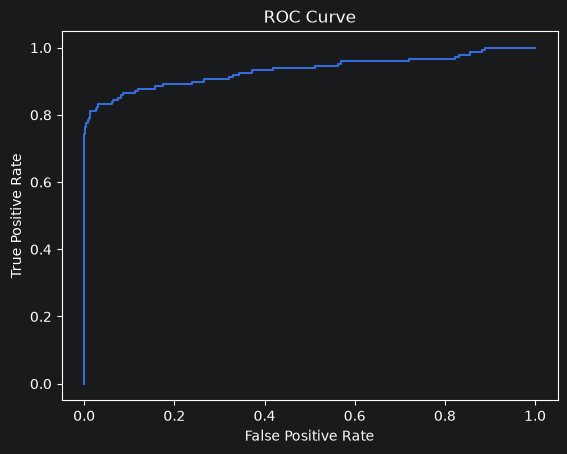

AUC:  0.9321364010120677


In [14]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = model.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

print('AUC: ', roc_auc_score(y_test, y_probs))


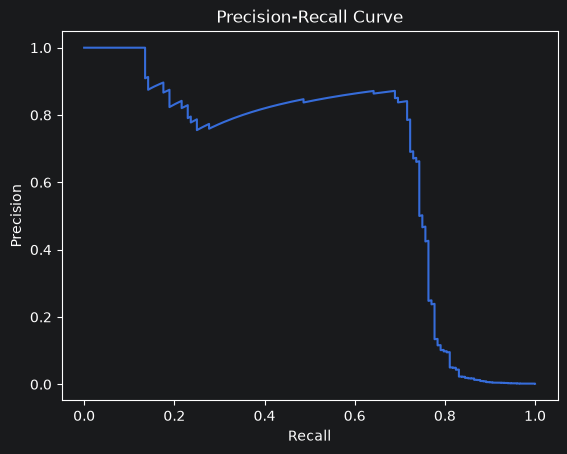

In [15]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)
plt.plot(recall, precision)
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()


In [16]:
#Balanceamento de Dados
#Undersampling

fraudes = df[df['Class'] == 1]
normais = df[df['Class'] == 0].sample(len(fraudes), random_state = 42)

df_under = pd.concat([fraudes, normais])


In [17]:
#Oversampling
from imblearn.over_sampling import SMOTE
smote = SMOTE()

x_res, y_res = smote.fit_resample(x, y)

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators= 50,
    max_depth= 10,
    class_weight= 'balanced',
    n_jobs= -1,
    random_state= 42
)

rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.67      0.80      0.73       148

    accuracy                           1.00     85443
   macro avg       0.83      0.90      0.86     85443
weighted avg       1.00      1.00      1.00     85443



In [19]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter= 1000))
])

pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_test)

In [20]:
threshold = 0.3
y_pred_custom = (y_probs > threshold).astype(int)
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.85      0.70      0.77       148

    accuracy                           1.00     85443
   macro avg       0.93      0.85      0.88     85443
weighted avg       1.00      1.00      1.00     85443



In [21]:
# Modelo Avançado - XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=10, # Ajuda com desbalanceamento
    use_label_encoder=False, # (Lembrando que este parâmetro é obsoleto)
    eval_metric='logloss'
)

# Use X maiúsculo para as features
xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(x_test)

C:\Users\Meirielly\PycharmProjects\Estudos_Python\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:59:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [22]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.94      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.97      0.89      0.93     85443
weighted avg       1.00      1.00      1.00     85443



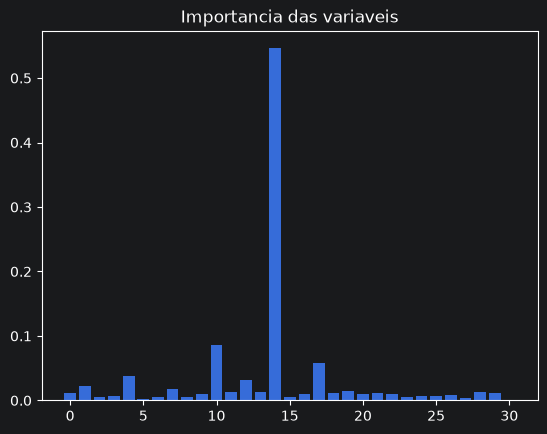

In [23]:
#Importancia das variaveis

import matplotlib.pyplot as plt

importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title('Importancia das variaveis')
plt.show()

In [24]:
#Ajuste de Hiperparâmetros

from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5],
    'n_estimators': [50, 100]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric= 'logloss'),
    param_grid,
    scoring= 'recall',
    cv= 3
)

grid.fit(x_train, y_train)
print('Melhor Modelo: ', grid.best_params_)


Melhor Modelo:  {'max_depth': 5, 'n_estimators': 100}


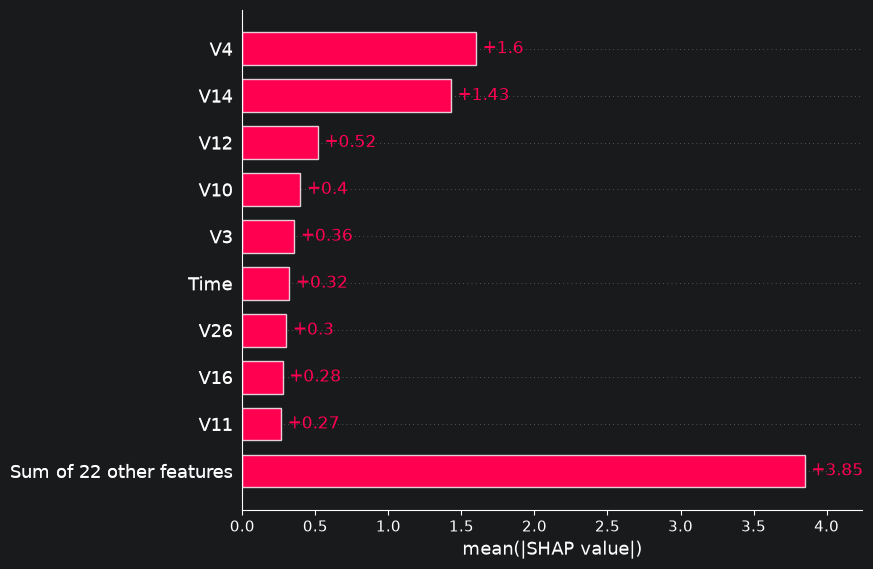

In [25]:
import shap

explainer = shap.Explainer(xgb)
shap_values = explainer(x_test[:100])

shap.plots.bar(shap_values)